# Binary classification (2 classes)

### Getting the data

In [1]:
# Scikit-Learn provides tools to access common dataset
# In this case we gonna download MNIST wich has images
# of digits handwritten

from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [2]:
# Scikit-Learn dataset have in general the same structure:
# DESCR: describing dataset
# data: A row (instance), column (attributes) structure with the data
# target: Containing labels

X, y = mnist["data"], mnist["target"]
X.shape

(70000, 784)

In [3]:
y.shape

(70000,)

<function matplotlib.pyplot.show(close=None, block=None)>

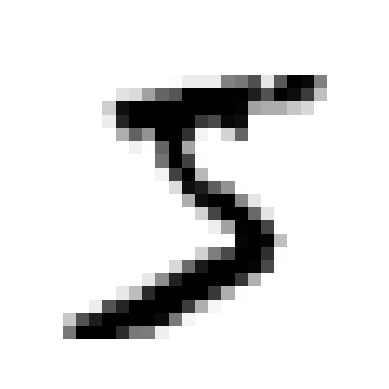

In [4]:
# Each instance row represents a 28x28 image. So we need to reshape it by dividing 
# the number of attributes by 28 using the function reshape
# Then we can show the letter with matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt

some_digit = X.values[0]
some_digit_image = some_digit.reshape(28, 28) # here we reshape the array in a 28x28 matrix by dividing 784 / 28

plt.imshow(some_digit_image, cmap=mpl.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show

In [5]:
# This looks like a five, and so the label says
y[0]

'5'

In [6]:
# As for ML is better to work with integeres than strings
# we cast the label values
import numpy as np

y = y.astype(np.uint8)

In [7]:
# This dataset is already split in a training set and test set
# so, let's get them in different variables
# It is important to remark that the dataset is shuffled this way
# so the split is straightforward

X_train, X_test, y_train, y_test = X[:6000], X[6000:], y[:6000], y[6000]

In [8]:
# To start and make things easier we'll try to identify one digit
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

In [9]:
# Using Stochastic Gradient Descend classifier (SGD) which is good for large datasets
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train.values, y_train_5)

SGDClassifier(random_state=42)

In [10]:
y_train_5

0        True
1       False
2       False
3       False
4       False
        ...  
5995    False
5996    False
5997    False
5998    False
5999    False
Name: class, Length: 6000, dtype: bool

In [11]:
# Now let's try to detect images with the number five
# This should return true
sgd_clf.predict([some_digit])


array([ True])

<function matplotlib.pyplot.show(close=None, block=None)>

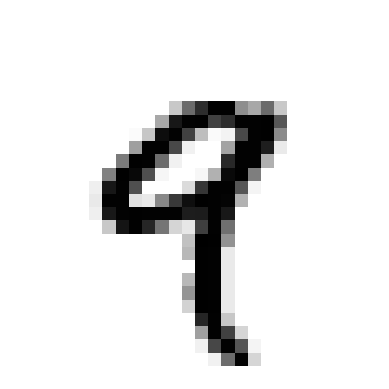

In [12]:
y.values[4]
nine_digit_from_4 = X.values[4]
nine_digit_from_4_image = nine_digit_from_4.reshape(28, 28)
plt.imshow(nine_digit_from_4_image, cmap=mpl.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show

In [13]:
# Now let's try with this nine
sgd_clf.predict([nine_digit_from_4])

array([False])

In [14]:
# Implementing cross validation manually
# This implementation does more or less the same that cross_val_score()

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

# # the method split from skfolds, returns a ndarray object. 
# # That's an special array from numpy that adds functionality
# NOTE: X has the keys "pixel1, pixel2, ..., pixelN"
#       to get the values from X we have to use X.values, that is the rows for columns "pixelX"
for train_index, test_index in skfolds.split(X_train.values, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train.values[train_index]
    y_train_folds = y_train_5.values[train_index]
    X_test_fold = X_train.values[test_index]
    y_test_fold = y_train_5.values[test_index]
    
    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))


0.9615
0.962
0.963


In [15]:
# Now let's compare results with cross_val_score function

from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.962 , 0.956 , 0.9665])

In [16]:
# Now let's create a not-5 base estimator 
# to check is result above where so great at is seems

from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

In [17]:
# Try our classifier
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.91 , 0.915, 0.918])

In [18]:
# This high score with this basic model shows that 
# accuracy is not good to evaluate a clasifier
# A better approach is a Confusion Matrix (Book page 92)
# With that said, let's create one by starting to get predictions

from sklearn.model_selection import cross_val_predict

y_train_predict = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [19]:
# The result will be the following Matrix:
# |TN FP|
# |FN TP|
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_5, y_train_predict)

array([[5375,  111],
       [ 120,  394]])

In [20]:
# Pretend perfection => FP=0, and FN=0
# for that we'll use the predictions as labels
confusion_matrix(y_train_5, y_train_5)

array([[5486,    0],
       [   0,  514]])

In [21]:
# Let's compute "precision" and "recall" using scikit-learn

from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_predict)# 0.78019
recall_score(y_train_5, y_train_predict) # 0.76653

0.7665369649805448

In [22]:
# The "Harmonic Mean" function, wich combines
# Precision and Recall is generally used
# as score here to evaluate performance

from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_predict)

0.7733071638861628

In [23]:
# SGDClassifier doesn't give direct access to the Threshold, but insted
# allows getting the decision scores, this way we can predict based
# on the threshold we want
# index 0, 11, 35, 47 corresponds to a 5
some_digit = X[46:47]
y_scores = sgd_clf.decision_function(some_digit)

threshold = 0
y_some_digit_pred = (y_scores > threshold)

y_some_digit_pred


/Users/javi/Projects/MachineLearning/ml_venv/lib/python3.10/site-packages/sklearn/base.py:443: UserWarning: X has feature names, but SGDClassifier was fitted without feature names
  warnings.warn(


array([False])

In [24]:
# Let's try with a higher threshold

some_digits = X[0:1]
threshold = 8000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred
# We can see here, that by raising the threshold, recall decreases. 
# That means that we can obtain more false negatives
# like in this case.
# We're are more strict in try to find real 5 (more precision)
# but we increase the risk to get false negatives

array([False])

In [25]:
# Let's try to find the "Sweet spot" between PRECISION and RECALL
# by using the "precision_recall_curve" function
from sklearn.metrics import precision_recall_curve

# first we get the decision function values using cross_val_predict
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method='decision_function')
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
thresholds

array([-2309765.11757512, -2079936.03425663, -2039970.91901927, ...,
         830440.47034494,   850868.83207321,   852681.43917402])

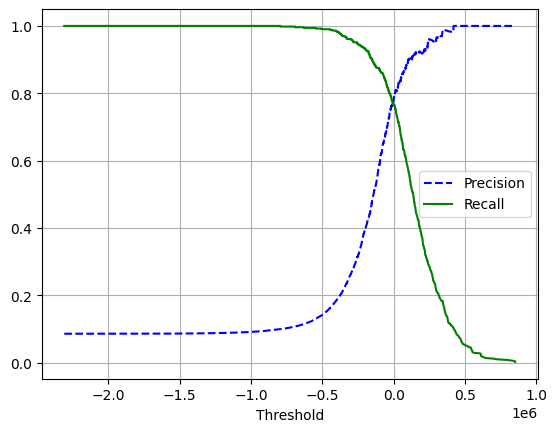

In [26]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label='Precision')
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.xlabel('Threshold')
    plt.legend(['Precision', 'Recall'], loc='center right')
    plt.grid()
    
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

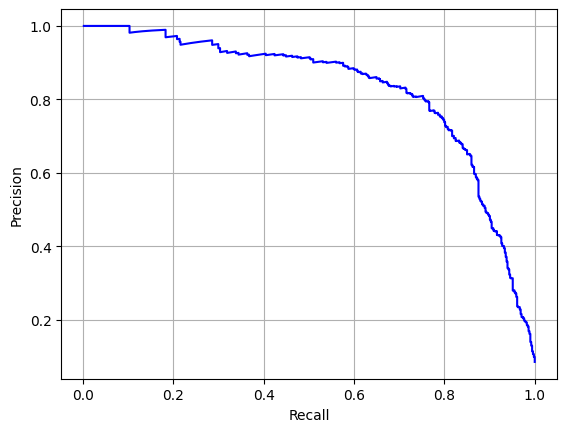

In [27]:
def plot_precision_vs_recall(precisions, recalls, desired_precision):
    plt.plot(recalls[:-1], precisions[:-1], "b-")
    #plt.plot(x, y, marker="o", markersize=20, markeredgecolor="red", markerfacecolor="green")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid()
    
plot_precision_vs_recall(precisions, recalls, 0.90)
plt.show()

In [28]:
# In the first graphic we can see that to achieve 90% of precision 
# we need to use a threshold about 8000
# The goal if to find the lower threshold possible to do that
# For this case we can use the function "np.argmax"
# argmax returns the first index of the max value, 
# that in our case will be True for precisions >= 0.90
# then we get the threshold of that index
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)] # 105660.23702487051

In [29]:
# Let's get all the scores bigger than the threshold we got for 0.90 precision
y_train_pred_90 = (y_scores >= threshold_90_precision)
y_train_pred_90

array([False, False, False, ..., False, False, False])

In [30]:
# Checking precision for this thresholds to confirm we're doing right
precision_score(y_train_5, y_train_pred_90)

0.9012345679012346

In [31]:
# Now computing recall
recall_score(y_train_5, y_train_pred_90)

0.5680933852140078

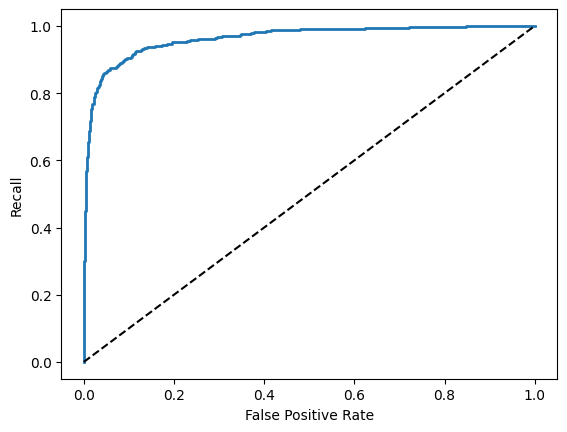

In [32]:
# Computing ROC (Receiver Operating Characteristic)

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0,1], [0,1], 'k--') #dashed diagonal
    plt.ylabel('Recall')
    plt.xlabel('False Positive Rate')

plot_roc_curve(fpr, tpr)
plt.show()

In [33]:
# Here computing ROC AUC (Area Under the Curve)
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

0.9641599203348885

#### Trying Random Forest Classifier

In [34]:
# Now let's train a RandomForestClassifier to compare
# This classifier doesn't have a decision_fuction. It has a predic_proba function instead.

from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")


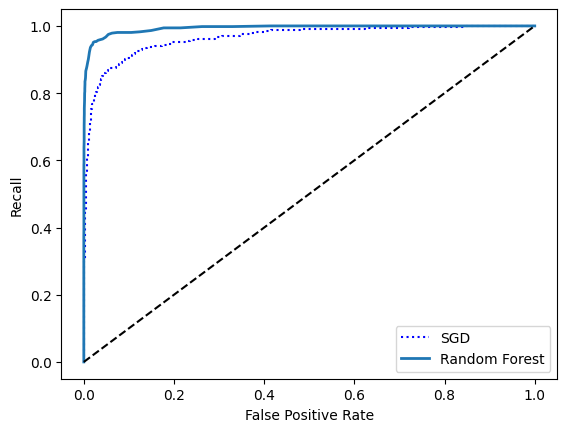

In [35]:
# To plot ROC curve, we need scores not probabilities
# so, we use a positive probability class as a score

y_scores_forest = y_probas_forest[:,1] # score = proba of positive class 
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5, y_scores_forest)

plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show()


In [36]:
# That ROC curve with the RandomForestClassifier looks much better
# So does the "roc_auc_score"
roc_auc_score(y_train_5, y_scores_forest)


0.9936162229715256

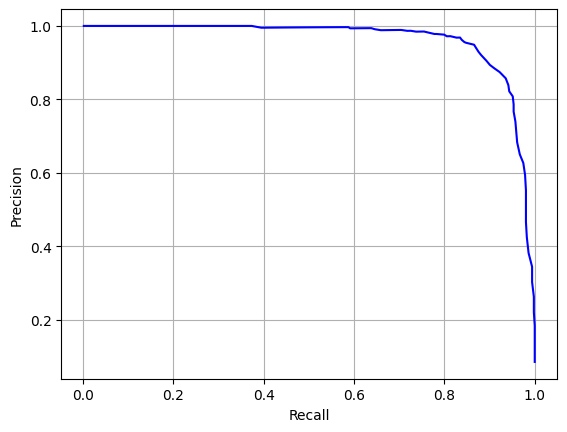

In [37]:
precisions_f, recalls_f, thresholds_f = precision_recall_curve(y_train_5, y_scores_forest)
plot_precision_vs_recall(precisions_f, recalls_f, 0.90)

In [38]:
# Loooks good. About 0.97 precision and 0.85 recall

## Multiclass Classification (Multinomial classification)

In [39]:
# There are some classifiers that suppport multiclass classification directly
# like Random Forest or Naive Bayes
# But also muulticlass classification can be done using several Binary Classifiers
# In this Case we'll use a SDGClassifier (binary) using a OvsO strategy
some_digit = X.values[0]
sgd_clf.fit(X_train.values, y_train) # y_train, not y_train_5
sgd_clf.predict([some_digit])

array([5], dtype=uint8)

In [40]:
 sgd_clf.predict([X.values[5995]])

array([7], dtype=uint8)

In [41]:
# Under the hood, sklearn train 10 binary classifiers!!!
# Let's call decision function to see that
some_digit_scores = sgd_clf.decision_function([some_digit])
some_digit_scores
# We got the score of each classifier
# The highest is the one corresponding to class 5

array([[-735711.69660953, -857058.38635209, -281086.00104909,
           8289.73273042, -616793.26669143,   29040.2961313 ,
        -492305.02284074, -834395.17091855, -318385.3774766 ,
        -363474.38706356]])

In [42]:
# Let get the index with highest score
np.argmax(some_digit_scores)

5

In [43]:
# Now let's check the class for that index
sgd_clf.classes_[5]

5

In [44]:
# See the classes we have
sgd_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [45]:
# Random Forest classifier doesn't need apply OvO or OvA because
# it can handle by it self multinomial classification
# Let's try it
forest_clf.fit(X_train.values, y_train)
forest_clf.predict([some_digit])


array([5], dtype=uint8)

In [46]:
# Let's check the list of probabilities for each digit
forest_clf.predict_proba([some_digit])
# we can see here that index = 5 has 0.8 wich is more much higher that others

array([[0.01, 0.03, 0.01, 0.11, 0.01, 0.8 , 0.01, 0.  , 0.01, 0.01]])

In [47]:
# Let's go back to SGDClassifier and evaluate it's accuracy
# by doing cross validation
cross_val_score(sgd_clf, X_train.values, y_train, cv=3, scoring="accuracy")

array([0.8565, 0.8715, 0.8635])

In [48]:
# Scaling the inputs to get more accuracy (should check that in chapter 2)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.8705, 0.8985, 0.8925])

### Error Analysis

In [49]:
# Let's create a confusion matrix to analyze performance

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
conf_mx = confusion_matrix(y_train, y_train_pred)
conf_mx

array([[572,   0,   1,   2,   1,   9,   3,   1,   3,   0],
       [  0, 637,   6,   3,   1,   5,   0,   1,  16,   2],
       [ 10,  12, 493,  11,  10,   4,  10,   9,  20,   2],
       [  3,   5,  21, 514,   1,  35,   1,   7,  11,  10],
       [  3,   2,   7,   0, 556,   2,  10,   8,   9,  26],
       [  5,   6,   5,  24,  14, 411,  10,   1,  25,  13],
       [  4,   4,   6,   0,   5,   6, 577,   1,   5,   0],
       [  3,   4,   7,   2,   9,   0,   1, 577,   3,  45],
       [  2,  19,  13,  16,   4,  10,   6,   3, 464,  14],
       [  7,   4,   5,   7,  15,   3,   0,  27,  11, 522]])

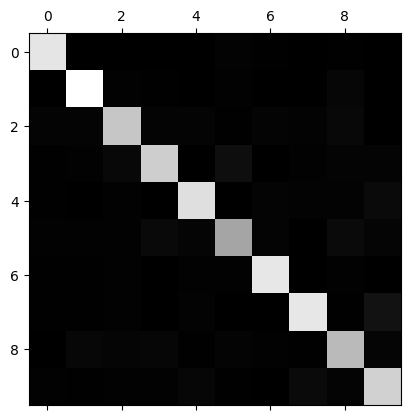

In [50]:
# Observe that the main diagonal has the highest values (positives).
# Which makes sense
# Let's see this data graphically to make it more clear
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

In [51]:
# Eache value of the matrix is the summation of
# the scores for a number
# To compute the error we need to divide the value in the matrix
# by the instance count of each class

row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums

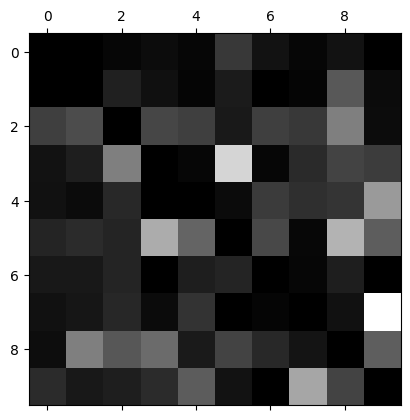

In [52]:
# Now, we fill the diagonal with 0 to remove the correct predictions
# and keep the errors
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.show()


In [53]:
# Observing the graphic above, we can see that
# 5 and 3 are often confused. Also 7 and 9
# With this info, we have to take action to fix this issues
# Let's plot 5 and 3 to start this analysis

# def plot_digits(digits, images_per_row):
#     images = digits.values[0].reshape(28, 28)
#     for d in digits.values[1:]:
#         d_image = d.reshape(28, 28)
#         images = np.concatenate((images, d_image))
#     plt.imshow(images, cmap=mpl.cm.binary, interpolation="nearest")
    

# cl_a, cl_b = 3, 4
# X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
# X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
# X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
# X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

# plt.figure(figsize=(3, 3))
# plt.subplot(221); plot_digits(X_aa[:25], images_per_row=5)
# plt.subplot(222); plot_digits(X_ab[:25], images_per_row=5)
# plt.subplot(223); plot_digits(X_ba[:25], images_per_row=5)
# plt.subplot(224); plot_digits(X_bb[:25], images_per_row=5)
# plt.show()
# Left pending to solve plot_digits function to be able to go on with the book reading

### Multilabel classification

In [54]:
# Simple example
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train.values, y_multilabel)

KNeighborsClassifier()

In [55]:
# We've trained the classifier with two labels. >= 7 and odd. 
# So now we can predict if a number has this characteristics

some_digit = X.values[0]
knn_clf.predict([some_digit])
# In this case we got that 5 is odd and < 7

array([[False,  True]])

In [56]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="weighted")

0.9529944300252725

### Multioutput Classification

In [76]:
# MC means that each label can belong to two or more classes. 
# In this example (where we'll try to detect noise on images)
# each pixel is a class. And each class can have a value
# between 0 and 255
# We start by adding some noice to MNIST images by using the randint() function

noise = np.random.randint(0, 100, (len(X_train.values), 784))
X_train_mod = X_train.values + noise
noise = np.random.randint(0, 100, (len(X_test.values), 784))
X_test_mod = X_test.values + noise
y_train_mod = X_train.values
y_test_mod = X_test.values


784

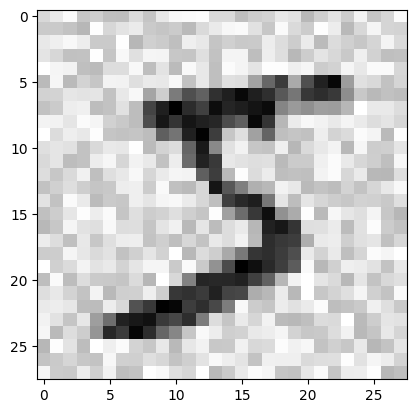

In [84]:
# Let's print the pixelated image
def plot_digit(digit):
    digit = digit.reshape(28, 28)
    plt.imshow(digit, cmap=mpl.cm.binary, interpolation="nearest")

plot_digit(X_train_mod[0])


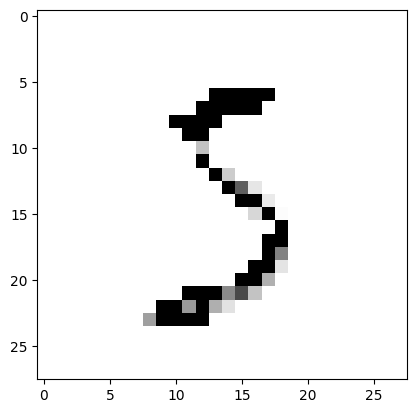

In [88]:
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([y_train_mod[0]])
plot_digit(clean_digit)